In [21]:
#data loading and analyzing

import pandas as pd

df=pd.read_csv('pamap2_combined.csv')
print(df.shape)

(88477, 54)


In [22]:
df.describe()

,timestamp,activityID,heartRate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_ori_w,ankle_ori_x,ankle_ori_y,ankle_ori_z
count,88477.000000,88477.000000,8034.000000,88419.000000,88419.000000,88419.000000,88419.000000,88419.000000,88419.000000,88419.000000,...,88417.000000,88417.000000,88417.000000,88417.000000,88417.000000,88417.000000,88417.000000,88417.000000,88417.000000,88417.000000
mean,56.259756,1.978989,97.027135,31.542320,-3.602455,4.270050,2.978569,-3.547096,4.287530,3.106949,...,0.011010,-0.019095,0.012474,-31.390384,2.031525,11.714737,0.409901,-0.109457,0.335271,-0.136083
std,28.492576,6.159212,19.758155,2.641774,6.037552,5.049437,3.705729,6.048429,5.072949,3.710707,...,0.838083,0.420913,1.177864,16.294765,28.557585,28.167692,0.270786,0.550278,0.358294,0.429625
min,5.640000,0.000000,73.000000,24.750000,-69.717600,-81.681200,-38.042400,-61.135600,-58.397200,-32.860800,...,-11.940400,-8.849780,-7.271180,-117.268000,-71.026700,-60.519300,-0.253628,-0.922574,-0.812822,-0.785453
25%,31.710000,0.000000,83.000000,30.187500,-9.127495,2.436740,0.827184,-9.031030,2.508905,1.024520,...,-0.025159,-0.032333,-0.021650,-45.450100,-20.254700,-6.023980,0.222550,-0.675549,0.081252,-0.541814
50%,56.290000,0.000000,93.000000,32.437500,-5.550530,3.912160,2.843820,-5.512930,3.937290,2.938870,...,0.007980,-0.006585,0.002062,-33.915900,-1.137100,9.736090,0.359059,-0.065343,0.295968,-0.269459
75%,80.860000,1.000000,102.000000,33.500000,0.741569,6.540265,5.885120,0.927520,6.545380,5.956600,...,0.037017,0.018855,0.022378,-14.223000,27.257200,38.364700,0.545499,0.373120,0.668766,0.278878
max,108.370000,24.000000,162.000000,34.687500,16.909200,65.430400,157.760000,15.769500,52.241700,40.770200,...,10.686700,4.356320,12.870400,15.057000,55.468300,71.924400,1.000000,0.865900,0.894005,0.764446


In [23]:
print(df.dtypes)

timestamp            float64
activityID             int64
heartRate            float64
hand_temperature     float64
hand_acc16_x         float64
hand_acc16_y         float64
hand_acc16_z         float64
hand_acc6_x          float64
hand_acc6_y          float64
hand_acc6_z          float64
hand_gyro_x          float64
hand_gyro_y          float64
hand_gyro_z          float64
hand_mag_x           float64
hand_mag_y           float64
hand_mag_z           float64
hand_ori_w           float64
hand_ori_x           float64
hand_ori_y           float64
hand_ori_z           float64
chest_temperature    float64
chest_acc16_x        float64
chest_acc16_y        float64
chest_acc16_z        float64
chest_acc6_x         float64
chest_acc6_y         float64
chest_acc6_z         float64
chest_gyro_x         float64
chest_gyro_y         float64
chest_gyro_z         float64
chest_mag_x          float64
chest_mag_y          float64
chest_mag_z          float64
chest_ori_w          float64
chest_ori_x   

In [24]:
miss = df.isnull().sum().sort_values(ascending=False)
print(miss[miss>0].to_string())


heartRate            80443
chest_gyro_x           124
chest_acc6_z           124
chest_temperature      124
chest_acc16_x          124
chest_acc16_y          124
chest_acc16_z          124
chest_acc6_x           124
chest_acc6_y           124
chest_ori_y            124
chest_ori_x            124
chest_gyro_y           124
chest_gyro_z           124
chest_mag_x            124
chest_mag_y            124
chest_mag_z            124
chest_ori_z            124
chest_ori_w            124
ankle_temperature       60
ankle_acc16_y           60
ankle_acc16_z           60
ankle_acc6_x            60
ankle_acc6_y            60
ankle_acc6_z            60
ankle_gyro_x            60
ankle_gyro_y            60
ankle_gyro_z            60
ankle_mag_x             60
ankle_mag_y             60
ankle_mag_z             60
ankle_ori_w             60
ankle_ori_x             60
ankle_ori_y             60
ankle_acc16_x           60
ankle_ori_z             60
hand_gyro_y             58
hand_ori_z              58
h

In [25]:
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print("dropped", before - after, "duplicates")

dropped 0 duplicates


In [26]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('pamap2_combined.csv')

metadata_cols = ['timestamp', 'activityID']
heart_col = 'heartRate'
sensor_cols = [c for c in df.columns if c not in metadata_cols + [heart_col]]

df[sensor_cols] = df[sensor_cols].apply(pd.to_numeric, errors='coerce')
df[heart_col] = pd.to_numeric(df[heart_col], errors='coerce')

#filling gaps in sensor data
df[sensor_cols] = df[sensor_cols].interpolate(method='linear', limit_direction='both', axis=0)
df[sensor_cols] = df[sensor_cols].ffill().bfill()

#median of heart rate from group of records realted to that specific activity
def fill_heartrate(group):
    median_val = group.median()
    if np.isnan(median_val):
        median_val = df[heart_col].median()  # else if for actovity heart beat is not there then median of whole column values
    return group.fillna(median_val)

df[heart_col] = df.groupby('activityID')[heart_col].transform(fill_heartrate)

remaining_nans = df[sensor_cols + [heart_col]].isnull().sum().sum()
print(f"Remaining NaNs after filling: {remaining_nans}")  # should be 0


Remaining NaNs after filling: 0


In [27]:
miss = df.isnull().sum().sort_values(ascending=False)
print(miss[miss>0].to_string())


Series([], )


In [28]:
print("STEP 9 activity mapping")
act_map = {
    0:'null',1:'lying',2:'sitting',3:'standing',4:'walking',5:'running',6:'cycling',
    7:'nordic_walking',9:'watching_tv',10:'computer_work',11:'car_driving',
    12:'ascending_stairs',13:'descending_stairs',16:'vacuum_cleaning',17:'ironing',
    18:'folding_laundry',19:'house_cleaning',20:'playing_soccer',24:'rope_jumping'
}
if 'activityID' in df.columns:
    df['activityName'] = df['activityID'].map(act_map)
    df['activityName'] = df['activityName'].fillna(df['activityID'].astype(str))
else:
    df['activityName'] = 'unknown'

STEP 9 activity mapping


In [29]:
df.describe()

,timestamp,activityID,heartRate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_ori_w,ankle_ori_x,ankle_ori_y,ankle_ori_z
count,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,...,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000,88477.000000
mean,56.259756,1.978989,95.908349,31.543107,-3.603896,4.270172,2.978326,-3.548515,4.287672,3.106737,...,0.010933,-0.019116,0.012444,-31.389791,2.018762,11.717239,0.409920,-0.109623,0.335406,-0.136115
std,28.492576,6.159212,15.115494,2.641811,6.037119,5.048533,3.705167,6.047954,5.072041,3.710114,...,0.838116,0.420839,1.178082,16.295329,28.560430,28.163590,0.270731,0.550213,0.358273,0.429584
min,5.640000,0.000000,73.000000,24.750000,-69.717600,-81.681200,-38.042400,-61.135600,-58.397200,-32.860800,...,-11.940400,-8.849780,-7.271180,-117.268000,-71.026700,-60.519300,-0.253628,-0.922574,-0.812822,-0.785453
25%,31.710000,0.000000,91.000000,30.187500,-9.126730,2.436970,0.827184,-9.031020,2.510490,1.024540,...,-0.025171,-0.032344,-0.021659,-45.448600,-20.267100,-6.023550,0.222557,-0.675585,0.081263,-0.541795
50%,56.290000,0.000000,92.000000,32.437500,-5.551610,3.911570,2.843700,-5.513540,3.934910,2.937950,...,0.007974,-0.006596,0.002062,-33.915900,-1.142050,9.736320,0.359575,-0.066216,0.295997,-0.269439
75%,80.860000,1.000000,92.000000,33.500000,0.741354,6.540260,5.885120,0.927518,6.545360,5.956580,...,0.037015,0.018853,0.022383,-14.222900,27.253200,38.364600,0.545499,0.373113,0.668795,0.278875
max,108.370000,24.000000,162.000000,34.687500,16.909200,65.430400,157.760000,15.769500,52.241700,40.770200,...,10.686700,4.356320,12.870400,15.057000,55.468300,71.924400,1.000000,0.865900,0.894005,0.764446


In [30]:
df.head()

,timestamp,activityID,heartRate,hand_temperature,hand_acc16_x,hand_acc16_y,hand_acc16_z,hand_acc6_x,hand_acc6_y,hand_acc6_z,...,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,ankle_ori_w,ankle_ori_x,ankle_ori_y,ankle_ori_z,activityName
0,8.38,0,104.0,30.0,2.37223,8.60074,3.51048,2.43954,8.76165,3.35465,...,0.009250,-0.017580,-61.1888,-38.9599,-58.1438,1.0,0.0,0.0,0.0,null
1,8.39,0,92.0,30.0,2.18837,8.56560,3.66179,2.39494,8.55081,3.64207,...,-0.004638,0.000368,-59.8479,-38.8919,-58.5253,1.0,0.0,0.0,0.0,null
2,8.40,0,92.0,30.0,2.37357,8.60107,3.54898,2.30514,8.53644,3.73280,...,0.000148,0.022495,-60.7361,-39.4138,-58.3999,1.0,0.0,0.0,0.0,null
3,8.41,0,92.0,30.0,2.07473,8.52853,3.66021,2.33528,8.53622,3.73277,...,-0.020301,0.011275,-60.4091,-38.7635,-58.3956,1.0,0.0,0.0,0.0,null
4,8.42,0,92.0,30.0,2.22936,8.83122,3.70000,2.23055,8.59741,3.76295,...,-0.014303,-0.002823,-61.5199,-39.3879,-58.2694,1.0,0.0,0.0,0.0,null


In [31]:
import pandas as pd
from sklearn.model_selection import train_test_split


train, test = train_test_split(df, test_size=0.2, shuffle=False)

print(train.shape, test.shape)


(70781, 55) (17696, 55)


In [32]:
def mag(x,y,z): return np.sqrt(x**2+y**2+z**2)
train['hand_mag']=mag(train.hand_acc16_x,train.hand_acc16_y,train.hand_acc16_z)
train['chest_mag']=mag(train.chest_acc16_x,train.chest_acc16_y,train.chest_acc16_z)
train['ankle_mag']=mag(train.ankle_acc16_x,train.ankle_acc16_y,train.ankle_acc16_z)


In [33]:
def mag(x,y,z): return np.sqrt(x**2+y**2+z**2)
test['hand_mag']=mag(test.hand_acc16_x,test.hand_acc16_y,test.hand_acc16_z)
test['chest_mag']=mag(test.chest_acc16_x,test.chest_acc16_y,test.chest_acc16_z)
test['ankle_mag']=mag(test.ankle_acc16_x,test.ankle_acc16_y,test.ankle_acc16_z)


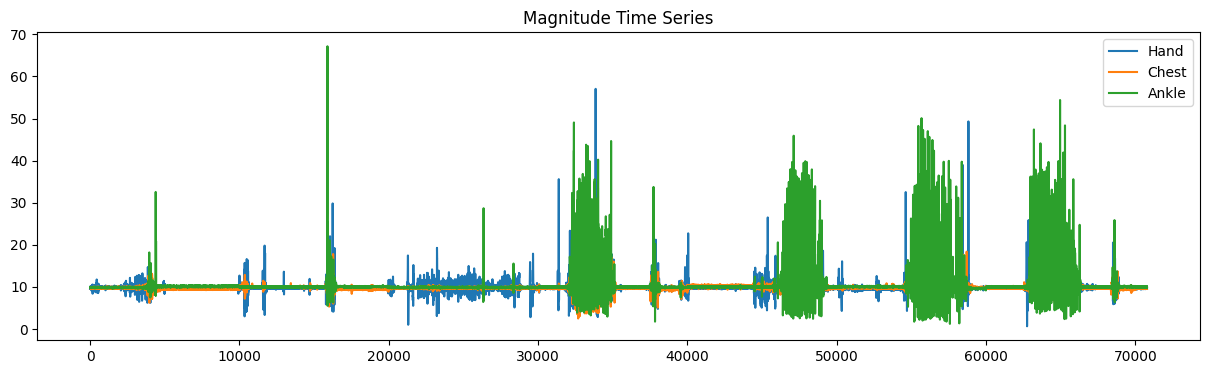

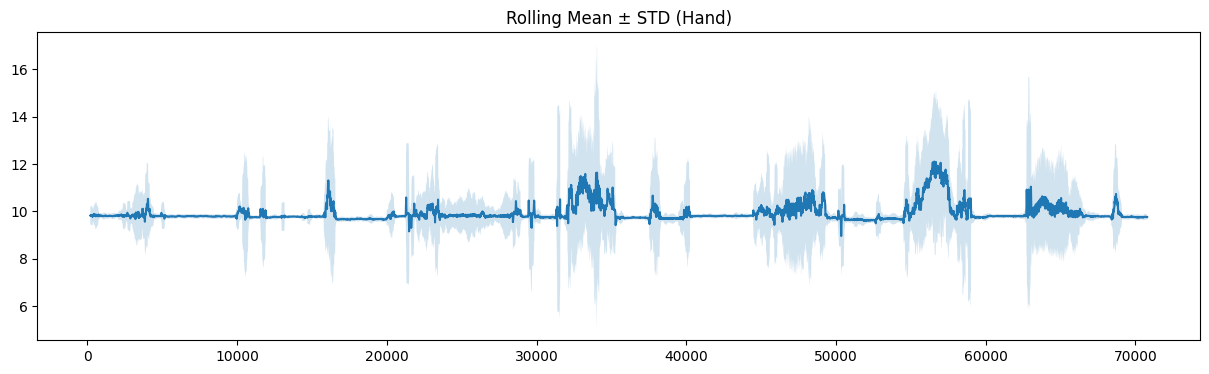

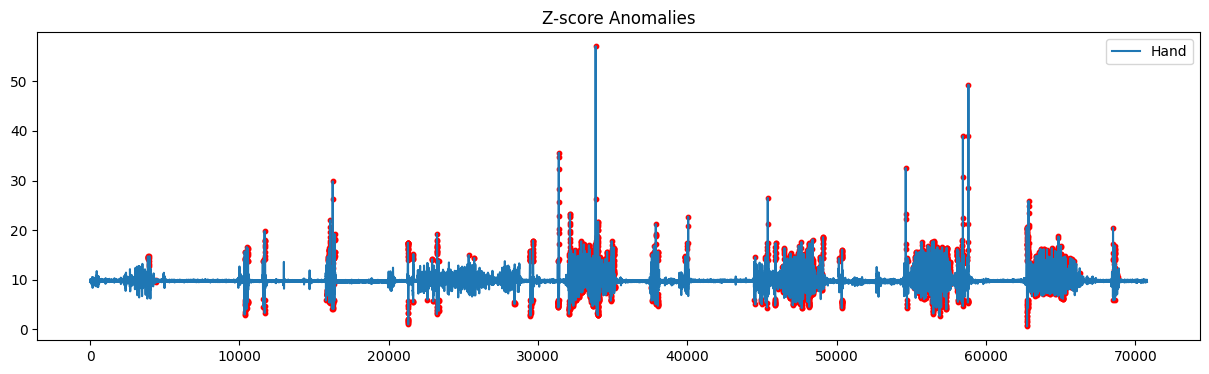

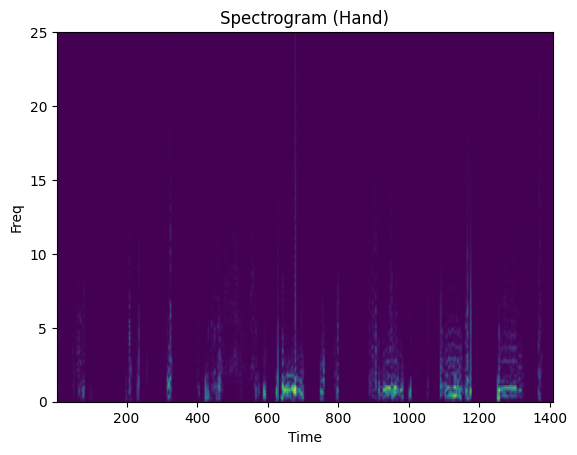

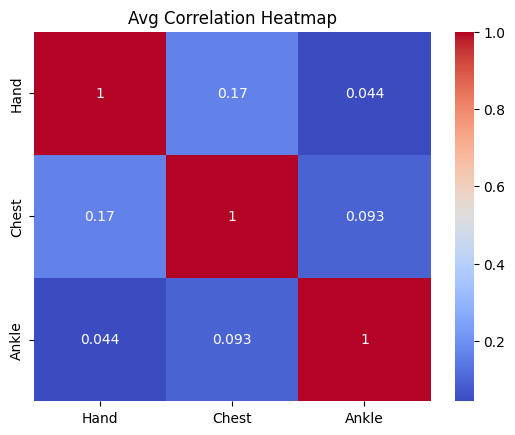

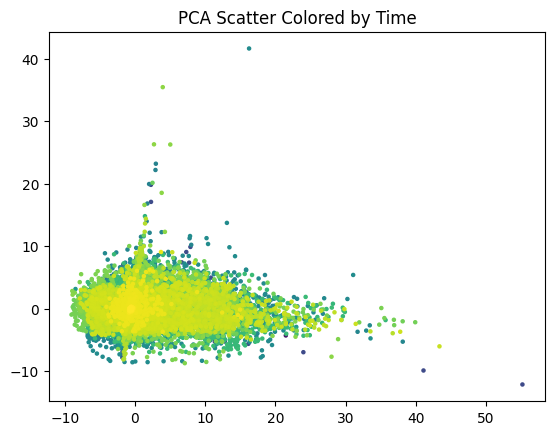

In [34]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import zscore
from scipy.signal import spectrogram
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

def mag(x,y,z): return np.sqrt(x**2+y**2+z**2)
train['hand_mag']=mag(train.hand_acc16_x,train.hand_acc16_y,train.hand_acc16_z)
train['chest_mag']=mag(train.chest_acc16_x,train.chest_acc16_y,train.chest_acc16_z)
train['ankle_mag']=mag(train.ankle_acc16_x,train.ankle_acc16_y,train.ankle_acc16_z)

plt.figure(figsize=(15,4))
plt.plot(train.hand_mag,label='Hand');plt.plot(train.chest_mag,label='Chest');plt.plot(train.ankle_mag,label='Ankle')
plt.legend();plt.title('Magnitude Time Series');plt.show()

roll=train[['hand_mag','chest_mag','ankle_mag']].rolling(200)
mean,std=roll.mean(),roll.std()
plt.figure(figsize=(15,4))
plt.plot(train.index,mean['hand_mag'])
plt.fill_between(train.index,mean['hand_mag']-std['hand_mag'],mean['hand_mag']+std['hand_mag'],alpha=0.2)
plt.title('Rolling Mean ± STD (Hand)');plt.show()

z=np.abs(zscore(train[['hand_mag','chest_mag','ankle_mag']],nan_policy='omit'))
anom=(z>3).any(axis=1)
plt.figure(figsize=(15,4))
plt.plot(train.hand_mag,label='Hand')
plt.scatter(train.index[anom],train.hand_mag[anom],color='r',s=10)
plt.title('Z-score Anomalies');plt.legend();plt.show()

f,t,Sxx=spectrogram(train.hand_mag[~np.isnan(train.hand_mag)],fs=50)
plt.pcolormesh(t,f,np.log(Sxx+1),shading='gouraud')
plt.title('Spectrogram (Hand)');plt.ylabel('Freq');plt.xlabel('Time');plt.show()

win,step=500,250;corrs=[]
for start in range(0,len(train)-win,step):
    c=train[['hand_mag','chest_mag','ankle_mag']].iloc[start:start+win].corr().values
    corrs.append(c)
avg_corr=np.mean(corrs,axis=0)
sns.heatmap(avg_corr,xticklabels=['Hand','Chest','Ankle'],yticklabels=['Hand','Chest','Ankle'],annot=True,cmap='coolwarm')
plt.title('Avg Correlation Heatmap');plt.show()

pca=PCA(n_components=2).fit_transform(train[['hand_mag','chest_mag','ankle_mag']].fillna(0))
plt.scatter(pca[:,0],pca[:,1],c=np.arange(len(pca)),s=5,cmap='viridis')
plt.title('PCA Scatter Colored by Time');plt.show()


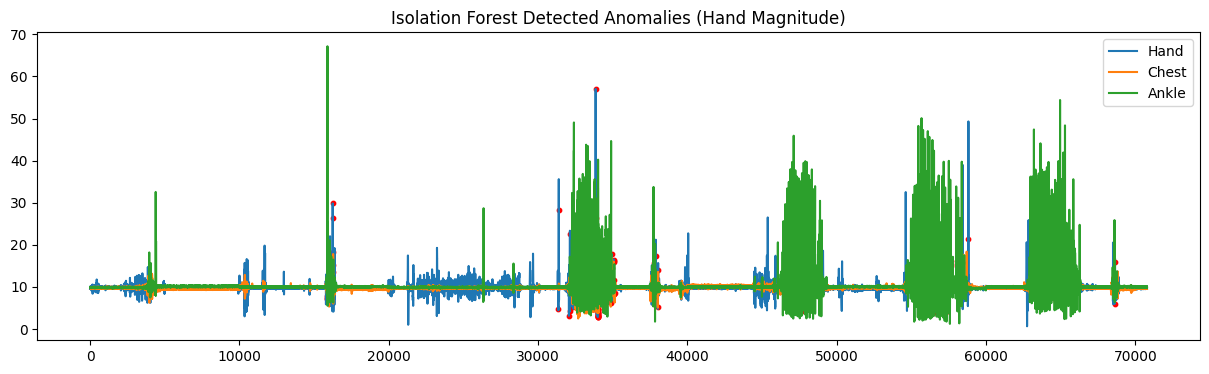

Number of anomalies detected: 708


In [35]:
#starting with anomaly detection with only heart rate and magnetometers values as baseline to get main anomalies

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

features = ['hand_mag','chest_mag','ankle_mag','heartRate']
X_train = train[features].fillna(0)

iso = IsolationForest(n_estimators=200, max_samples='auto', contamination=0.01, random_state=42)
train['anomaly_iso'] = iso.fit_predict(X_train)
train['anomaly_iso'] = train['anomaly_iso'].map({1:0,-1:1})

plt.figure(figsize=(15,4))
plt.plot(train.hand_mag,label='Hand')
plt.plot(train.chest_mag,label='Chest')
plt.plot(train.ankle_mag,label='Ankle')
plt.scatter(train.index[train['anomaly_iso']==1], train.hand_mag[train['anomaly_iso']==1], color='r', s=10)
plt.title('Isolation Forest Detected Anomalies (Hand Magnitude)')
plt.legend();plt.show()

print("Number of anomalies detected:", train['anomaly_iso'].sum())


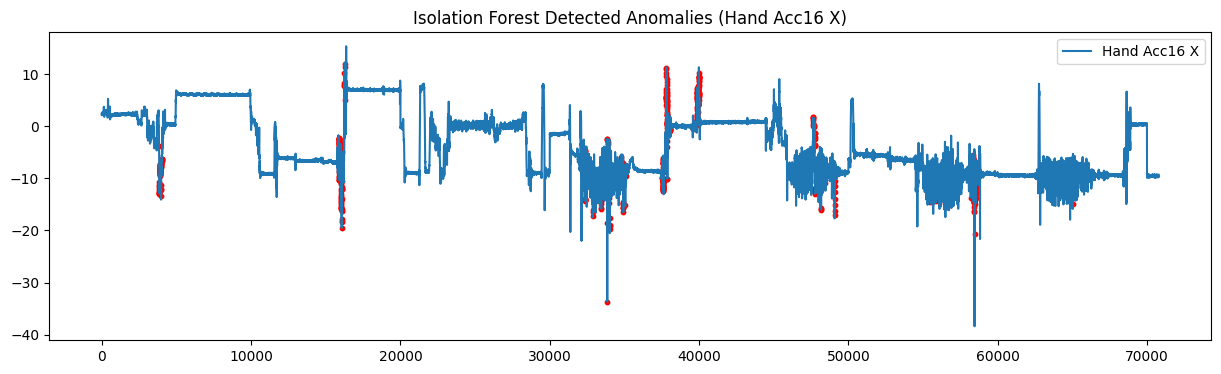

Number of anomalies detected: 708


In [36]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

features = [
    'hand_acc16_x','hand_acc16_y','hand_acc16_z',
    'hand_acc6_x','hand_acc6_y','hand_acc6_z',
    'hand_gyro_x','hand_gyro_y','hand_gyro_z',
    'hand_mag_x','hand_mag_y','hand_mag_z',
    
    'chest_acc16_x','chest_acc16_y','chest_acc16_z',
    'chest_acc6_x','chest_acc6_y','chest_acc6_z',
    'chest_gyro_x','chest_gyro_y','chest_gyro_z',
    'chest_mag_x','chest_mag_y','chest_mag_z',
    
    'ankle_acc16_x','ankle_acc16_y','ankle_acc16_z',
    'ankle_acc6_x','ankle_acc6_y','ankle_acc6_z',
    'ankle_gyro_x','ankle_gyro_y','ankle_gyro_z',
    'ankle_mag_x','ankle_mag_y','ankle_mag_z',
    
    'heartRate'
]

X_train = train[features].fillna(0)

iso = IsolationForest(n_estimators=300, max_samples='auto', contamination=0.01, random_state=42)
train['anomaly_iso_full'] = iso.fit_predict(X_train)
train['anomaly_iso_full'] = train['anomaly_iso_full'].map({1:0,-1:1})

plt.figure(figsize=(15,4))
plt.plot(train.index, train.hand_acc16_x, label='Hand Acc16 X')
plt.scatter(train.index[train['anomaly_iso_full']==1], train.hand_acc16_x[train['anomaly_iso_full']==1], color='r', s=10)
plt.title('Isolation Forest Detected Anomalies (Hand Acc16 X)')
plt.legend();plt.show()

print("Number of anomalies detected:", train['anomaly_iso_full'].sum())


In [37]:
import numpy as np

# Compute z-scores for hand, chest, ankle magnitudes and heart rate
z_hand = np.abs((train['hand_mag'] - train['hand_mag'].mean()) / train['hand_mag'].std())
z_chest = np.abs((train['chest_mag'] - train['chest_mag'].mean()) / train['chest_mag'].std())
z_ankle = np.abs((train['ankle_mag'] - train['ankle_mag'].mean()) / train['ankle_mag'].std())
z_hr = np.abs((train['heartRate'] - train['heartRate'].mean()) / train['heartRate'].std())

# Mark anomaly if any exceeds threshold (3 std deviations)
train['true_anomaly'] = ((z_hand > 3) | (z_chest > 3) | (z_ankle > 3) | (z_hr > 3)).astype(int)


In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

y_true = train['true_anomaly']
y_pred = train['anomaly_iso_full']

acc = accuracy_score(y_true, y_pred)
print("Accuracy:", acc*100)
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))


Accuracy: 89.41947697828513
Precision: 0.4872881355932203
Recall: 0.046178557087404634
F1-score: 0.08436239149040226

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94     63310
           1       0.49      0.05      0.08      7471

    accuracy                           0.89     70781
   macro avg       0.69      0.52      0.51     70781
weighted avg       0.85      0.89      0.85     70781



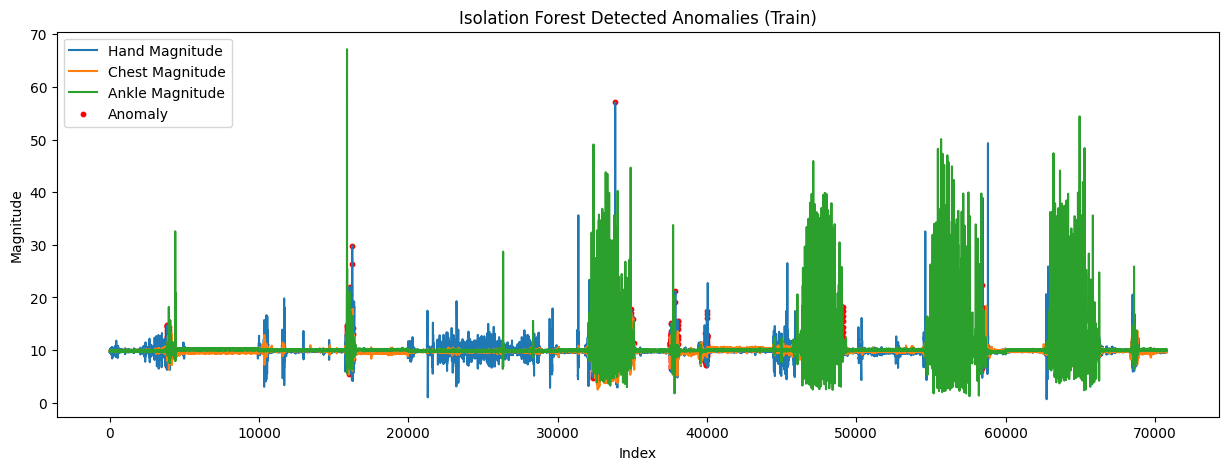

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(train.index, train['hand_mag'], label='Hand Magnitude')
plt.plot(train.index, train['chest_mag'], label='Chest Magnitude')
plt.plot(train.index, train['ankle_mag'], label='Ankle Magnitude')
plt.scatter(train.index[train['anomaly_iso_full']==1], 
            train['hand_mag'][train['anomaly_iso_full']==1], color='r', s=10, label='Anomaly')
plt.title('Isolation Forest Detected Anomalies (Train)')
plt.xlabel('Index')
plt.ylabel('Magnitude')
plt.legend()
plt.show()


In [40]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(n_estimators=300, max_samples='auto', contamination=0.01, random_state=42)
X_test = test[features].fillna(0)
test['anomaly_iso'] = iso.fit_predict(X_test)
test['anomaly_iso']=test['anomaly_iso'].map({1:0,-1:1})

# Pseudo-labels for test
z_hand = np.abs((test['hand_mag'] - test['hand_mag'].mean())/test['hand_mag'].std())
z_chest = np.abs((test['chest_mag'] - test['chest_mag'].mean())/test['chest_mag'].std())
z_ankle = np.abs((test['ankle_mag'] - test['ankle_mag'].mean())/test['ankle_mag'].std())
z_hr = np.abs((test['heartRate'] - test['heartRate'].mean())/test['heartRate'].std())
test['true_anomaly'] = ((z_hand>3)|(z_chest>3)|(z_ankle>3)|(z_hr>3)).astype(int)

# Test metrics
y_true, y_pred = test['true_anomaly'], test['anomaly_iso']
print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Test Precision:", precision_score(y_true, y_pred))
print("Test Recall:", recall_score(y_true, y_pred))
print("Test F1-score:", f1_score(y_true, y_pred))


Test Accuracy: 0.9300406871609403
Test Precision: 0.8305084745762712
Test Recall: 0.10848708487084871
Test F1-score: 0.1919060052219321


Accuracy: 0.9004958957912435
Precision: 0.8022598870056498
Recall: 0.07602730558158212
F1-score: 0.13889228512043036

Classification Report:
               precision    recall  f1-score   support

           0       0.90      1.00      0.95     63310
           1       0.80      0.08      0.14      7471

    accuracy                           0.90     70781
   macro avg       0.85      0.54      0.54     70781
weighted avg       0.89      0.90      0.86     70781



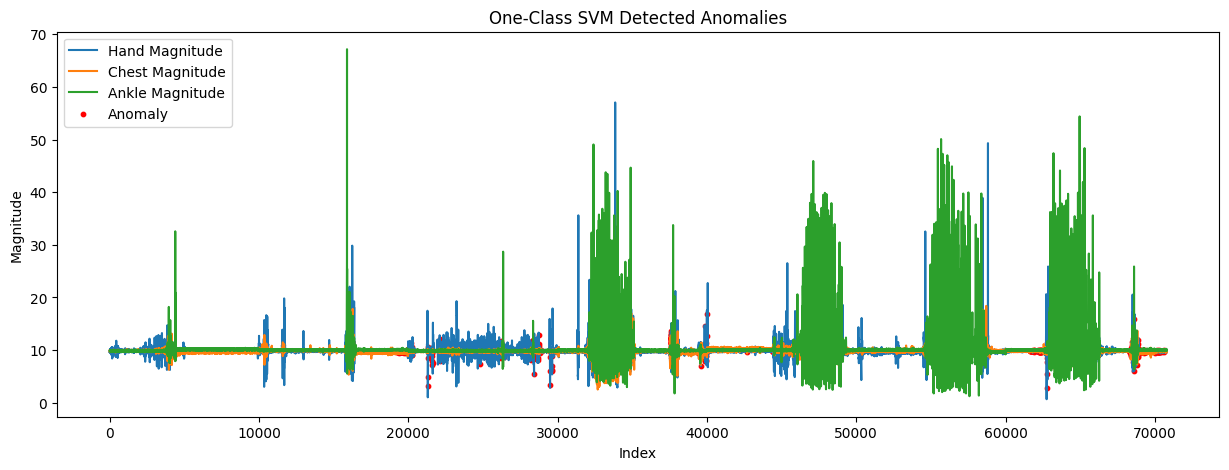

In [41]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

features = [
    'hand_acc16_x','hand_acc16_y','hand_acc16_z',
    'hand_acc6_x','hand_acc6_y','hand_acc6_z',
    'hand_gyro_x','hand_gyro_y','hand_gyro_z',
    'hand_mag_x','hand_mag_y','hand_mag_z',
    'chest_acc16_x','chest_acc16_y','chest_acc16_z',
    'chest_acc6_x','chest_acc6_y','chest_acc6_z',
    'chest_gyro_x','chest_gyro_y','chest_gyro_z',
    'chest_mag_x','chest_mag_y','chest_mag_z',
    'ankle_acc16_x','ankle_acc16_y','ankle_acc16_z',
    'ankle_acc6_x','ankle_acc6_y','ankle_acc6_z',
    'ankle_gyro_x','ankle_gyro_y','ankle_gyro_z',
    'ankle_mag_x','ankle_mag_y','ankle_mag_z',
    'heartRate'
]

X_train = train[features].fillna(0)

svm = OneClassSVM(kernel='linear', gamma='auto', nu=0.01)
train['anomaly_svm'] = svm.fit_predict(X_train)
train['anomaly_svm'] = train['anomaly_svm'].map({1:0,-1:1})

z_hand = np.abs((train['hand_mag'] - train['hand_mag'].mean())/train['hand_mag'].std())
z_chest = np.abs((train['chest_mag'] - train['chest_mag'].mean())/train['chest_mag'].std())
z_ankle = np.abs((train['ankle_mag'] - train['ankle_mag'].mean())/train['ankle_mag'].std())
z_hr = np.abs((train['heartRate'] - train['heartRate'].mean())/train['heartRate'].std())
train['true_anomaly'] = ((z_hand>3)|(z_chest>3)|(z_ankle>3)|(z_hr>3)).astype(int)

y_true = train['true_anomaly']
y_pred = train['anomaly_svm']

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

plt.figure(figsize=(15,5))
plt.plot(train.index, train['hand_mag'], label='Hand Magnitude')
plt.plot(train.index, train['chest_mag'], label='Chest Magnitude')
plt.plot(train.index, train['ankle_mag'], label='Ankle Magnitude')
plt.scatter(train.index[train['anomaly_svm']==1], 
            train['hand_mag'][train['anomaly_svm']==1], color='r', s=10, label='Anomaly')
plt.title('One-Class SVM Detected Anomalies')
plt.xlabel('Index')
plt.ylabel('Magnitude')
plt.legend()
plt.show()


In [42]:
print("Train Total Anomalies Detected:", train['anomaly_svm'].sum())

Train Total Anomalies Detected: 708


Test Total Anomalies Detected: 3309
Test Accuracy: 0.7364376130198915
Test Precision: 0.0
Test Recall: 0.0
Test F1-score: 0.0

Test Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.80      0.85     16341
           1       0.00      0.00      0.00      1355

    accuracy                           0.74     17696
   macro avg       0.45      0.40      0.42     17696
weighted avg       0.84      0.74      0.78     17696

total test length:  17696


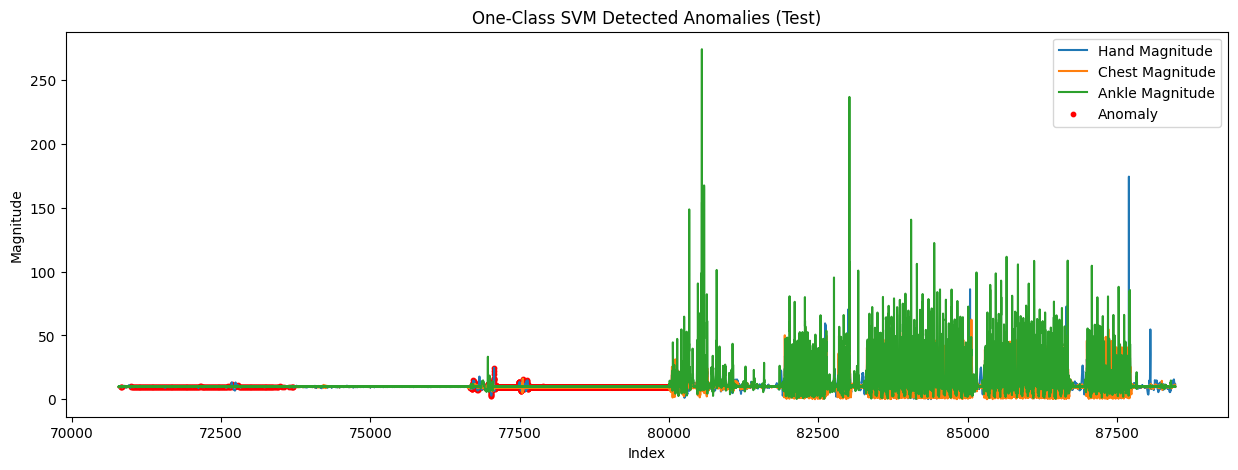

In [43]:
X_test = test[features].fillna(0)
test['anomaly_svm'] = svm.predict(X_test)
test['anomaly_svm']=test['anomaly_svm'].map({1:0,-1:1})

# Pseudo-labels for test
z_hand = np.abs((test['hand_mag'] - test['hand_mag'].mean())/test['hand_mag'].std())
z_chest = np.abs((test['chest_mag'] - test['chest_mag'].mean())/test['chest_mag'].std())
z_ankle = np.abs((test['ankle_mag'] - test['ankle_mag'].mean())/test['ankle_mag'].std())
z_hr = np.abs((test['heartRate'] - test['heartRate'].mean())/test['heartRate'].std())
test['true_anomaly'] = ((z_hand>3)|(z_chest>3)|(z_ankle>3)|(z_hr>3)).astype(int)

# Metrics and total anomalies - Test
y_true, y_pred = test['true_anomaly'], test['anomaly_svm']
print("Test Total Anomalies Detected:", test['anomaly_svm'].sum())
print("Test Accuracy:", accuracy_score(y_true, y_pred))
print("Test Precision:", precision_score(y_true, y_pred))
print("Test Recall:", recall_score(y_true, y_pred))
print("Test F1-score:", f1_score(y_true, y_pred))
print("\nTest Classification Report:\n", classification_report(y_true, y_pred))
print("total test length: ",len(test))

plt.figure(figsize=(15,5))
plt.plot(test.index, test['hand_mag'], label='Hand Magnitude')
plt.plot(test.index, test['chest_mag'], label='Chest Magnitude')
plt.plot(test.index, test['ankle_mag'], label='Ankle Magnitude')
plt.scatter(test.index[test['anomaly_svm']==1], test['hand_mag'][test['anomaly_svm']==1], color='r', s=10, label='Anomaly')
plt.title('One-Class SVM Detected Anomalies (Test)')
plt.xlabel('Index')
plt.ylabel('Magnitude')
plt.legend()
plt.show()


Total anomalies detected: 885
Accuracy: 0.9136272703640494
Precision: 0.15028248587570622
Recall: 0.01893777587925388
F1-score: 0.0336368234699039

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.99      0.95     81454
           1       0.15      0.02      0.03      7023

    accuracy                           0.91     88477
   macro avg       0.54      0.50      0.49     88477
weighted avg       0.86      0.91      0.88     88477



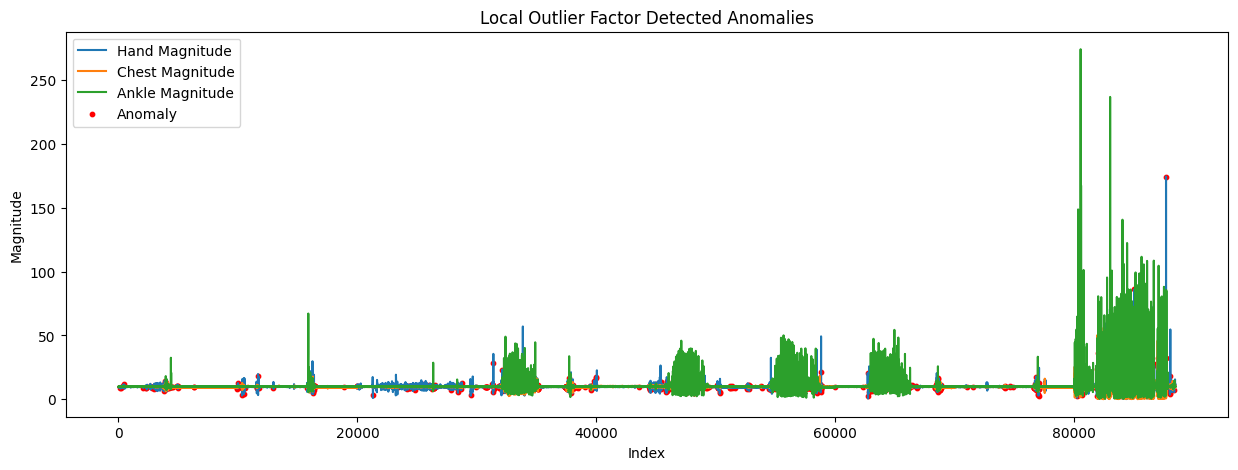

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

df['hand_mag'] = np.sqrt(df['hand_acc16_x']**2 + df['hand_acc16_y']**2 + df['hand_acc16_z']**2)
df['chest_mag'] = np.sqrt(df['chest_acc16_x']**2 + df['chest_acc16_y']**2 + df['chest_acc16_z']**2)
df['ankle_mag'] = np.sqrt(df['ankle_acc16_x']**2 + df['ankle_acc16_y']**2 + df['ankle_acc16_z']**2)

df_clean = df[['hand_mag','chest_mag','ankle_mag','heartRate']].dropna()

X = df_clean[['hand_mag','chest_mag','ankle_mag','heartRate']]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01)
df_clean['anomaly_lof'] = lof.fit_predict(X)
df_clean['anomaly_lof']=df_clean['anomaly_lof'].map({1:0,-1:1})

z_hand = np.abs((df_clean['hand_mag'] - df_clean['hand_mag'].mean())/df_clean['hand_mag'].std())
z_chest = np.abs((df_clean['chest_mag'] - df_clean['chest_mag'].mean())/df_clean['chest_mag'].std())
z_ankle = np.abs((df_clean['ankle_mag'] - df_clean['ankle_mag'].mean())/df_clean['ankle_mag'].std())
z_hr = np.abs((df_clean['heartRate'] - df_clean['heartRate'].mean())/df_clean['heartRate'].std())
df_clean['true_anomaly'] = ((z_hand>3)|(z_chest>3)|(z_ankle>3)|(z_hr>3)).astype(int)

y_true = df_clean['true_anomaly']
y_pred = df_clean['anomaly_lof']

print("Total anomalies detected:", df_clean['anomaly_lof'].sum())
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1-score:", f1_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred))

plt.figure(figsize=(15,5))
plt.plot(df_clean.index, df_clean['hand_mag'], label='Hand Magnitude')
plt.plot(df_clean.index, df_clean['chest_mag'], label='Chest Magnitude')
plt.plot(df_clean.index, df_clean['ankle_mag'], label='Ankle Magnitude')
plt.scatter(df_clean.index[df_clean['anomaly_lof']==1], df_clean['hand_mag'][df_clean['anomaly_lof']==1], color='r', s=10, label='Anomaly')
plt.title('Local Outlier Factor Detected Anomalies')
plt.xlabel('Index')
plt.ylabel('Magnitude')
plt.legend()
plt.show()


C:\Users\aishw\AppData\Local\Temp\ipykernel_21960\2670550095.py:26: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[all_accel_cols + ['heartRate']] = df[all_accel_cols + ['heartRate']].fillna(method='ffill').fillna(method='bfill')


Matrix Profile anomalies detected: 1076
Accuracy: 0.9535020400782124


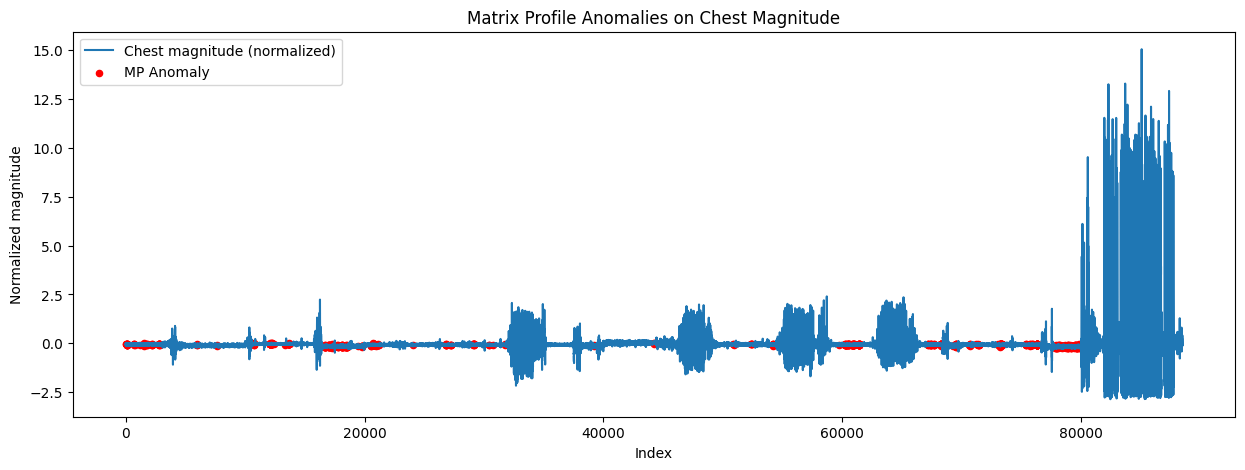

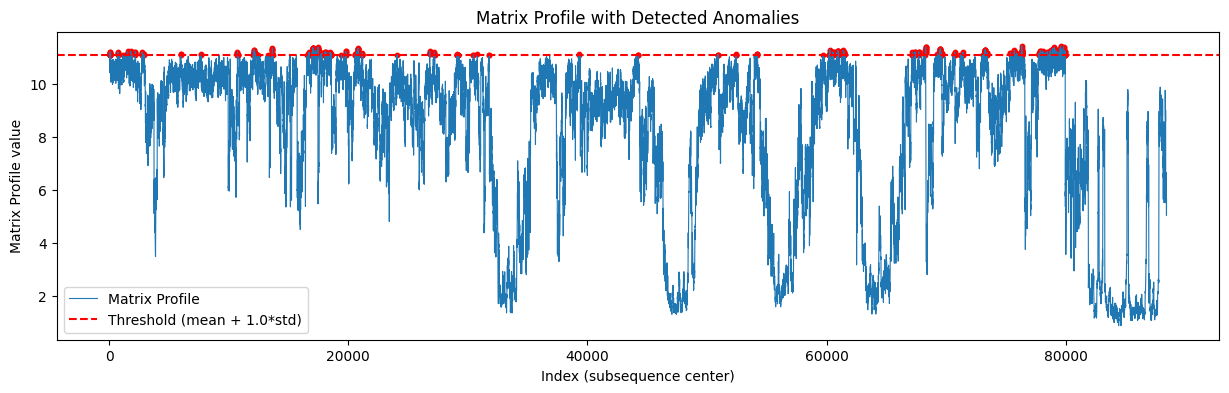

In [46]:
# Full PAMAP2 preprocessing + Matrix Profile anomaly detection
# Requirements: pandas, numpy, matplotlib, scikit-learn, stumpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import stumpy

# ----- 1) Load dataset -----
df = pd.read_csv('pamap2_combined.csv')

# ----- 2) Define columns -----
cols_hand = ['hand_acc16_x','hand_acc16_y','hand_acc16_z']
cols_chest = ['chest_acc16_x','chest_acc16_y','chest_acc16_z']
cols_ankle = ['ankle_acc16_x','ankle_acc16_y','ankle_acc16_z']
all_accel_cols = cols_hand + cols_chest + cols_ankle
aux_cols = ['heartRate', 'activityID', 'timestamp']  # reference columns

# ----- 3) Make numeric and handle missing -----
df[all_accel_cols + ['heartRate']] = df[all_accel_cols + ['heartRate']].apply(pd.to_numeric, errors='coerce')

# Interpolate missing values linearly, then forward/backward fill
df[all_accel_cols + ['heartRate']] = df[all_accel_cols + ['heartRate']].interpolate(method='linear', limit_direction='both')
df[all_accel_cols + ['heartRate']] = df[all_accel_cols + ['heartRate']].fillna(method='ffill').fillna(method='bfill')

# Ensure all acceleration columns are floats
df[all_accel_cols] = df[all_accel_cols].astype(float)

# ----- 4) Compute vector magnitudes -----
df['hand_mag']  = np.sqrt(np.sum(df[cols_hand].values.astype(float)**2, axis=1))
df['chest_mag'] = np.sqrt(np.sum(df[cols_chest].values.astype(float)**2, axis=1))
df['ankle_mag'] = np.sqrt(np.sum(df[cols_ankle].values.astype(float)**2, axis=1))

# ----- 5) Normalize chest signal for MP -----
scaler = StandardScaler()
df['chest_mag_norm'] = scaler.fit_transform(df[['chest_mag']])
ts = df['chest_mag_norm'].values.astype(float)

# Safety check: no NaNs
if np.isnan(ts).any():
    raise ValueError("NaNs present in time series after preprocessing!")

# ----- 6) Compute Matrix Profile -----
m = 100  # subsequence length
if len(ts) <= m:
    raise ValueError(f"Time series too short for m={m}")

mp = stumpy.stump(ts, m)  # shape (n-m+1, 2)
matrix_profile = np.array(mp[:,0], dtype=float)  # ensure float

# Replace any NaNs with mean
matrix_profile = np.nan_to_num(matrix_profile, nan=np.nanmean(matrix_profile))

# Align MP to subsequence centers
mp_positions = np.arange(len(matrix_profile)) + (m // 2)

# ----- 7) Detect anomalies using threshold -----
k = 1.0
threshold = np.mean(matrix_profile) + k * np.std(matrix_profile)
anomaly_indices = np.where(matrix_profile > threshold)[0]
anomaly_centers = anomaly_indices + (m // 2)
valid_centers = anomaly_centers[anomaly_centers < len(df)]

df['mp_anomaly'] = 0
df.loc[df.index[valid_centers], 'mp_anomaly'] = 1

# ----- 8) Z-score based pseudo-labels (for evaluation only) -----
z_hand  = np.abs((df['hand_mag']  - df['hand_mag'].mean())  / df['hand_mag'].std())
z_chest = np.abs((df['chest_mag'] - df['chest_mag'].mean()) / df['chest_mag'].std())
z_ankle = np.abs((df['ankle_mag'] - df['ankle_mag'].mean()) / df['ankle_mag'].std())
df['true_anomaly'] = ((z_hand > 3) | (z_chest > 3) | (z_ankle > 3)).astype(int)

# ----- 9) Evaluation -----
y_true, y_pred = df['true_anomaly'], df['mp_anomaly']
print("Matrix Profile anomalies detected:", df['mp_anomaly'].sum())
print("Accuracy:", accuracy_score(y_true, y_pred))


# ----- 10) Plot normalized chest signal + MP anomalies -----
plt.figure(figsize=(15,5))
plt.plot(df['chest_mag_norm'], label='Chest magnitude (normalized)')
plt.scatter(df.index[df['mp_anomaly']==1], df['chest_mag_norm'][df['mp_anomaly']==1],
            color='red', s=20, label='MP Anomaly')
plt.xlabel('Index')
plt.ylabel('Normalized magnitude')
plt.title('Matrix Profile Anomalies on Chest Magnitude')
plt.legend()
plt.show()

# ----- 11) Plot Matrix Profile -----
plt.figure(figsize=(15,4))
plt.plot(mp_positions, matrix_profile, label='Matrix Profile', linewidth=0.8)
plt.axhline(threshold, color='r', linestyle='--', label=f'Threshold (mean + {k}*std)')
plt.scatter(mp_positions[anomaly_indices], matrix_profile[anomaly_indices], color='red', s=10)
plt.xlabel('Index (subsequence center)')
plt.ylabel('Matrix Profile value')
plt.title('Matrix Profile with Detected Anomalies')
plt.legend()
plt.show()
